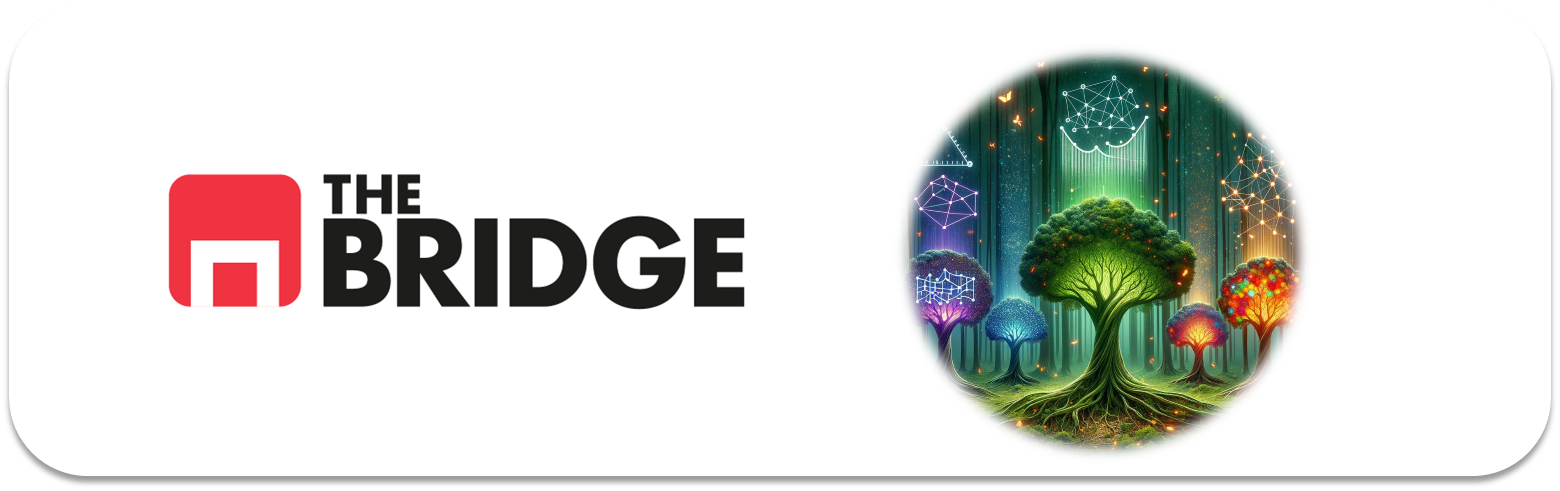

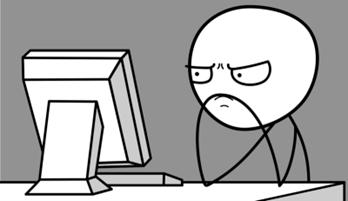

Para ejercitarte y afianzar lo aprendido sobre **Clasificacion con Árboles de decisión**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [2]:
import numpy as np
import pandas as pd
import sklearn
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from pprint import pprint


### Ejercicio 1

Genera un conjunto de datos de lunas usando 

```python
make_moons(n_samples=10000, noise=0.4)
```

La función make_moons se encuentra en el módulo `datasets` de `sklearn`. Juega con ella para ver qué tipo de datos genera, y  crea un X_moons y un y_moons. Visualiza las moons con un scatter plot de las dos features de X_moons. (ojo X_moons es un array de numpy de dos dimesiones para acceder a la primera X_moons[:,0] y para la segunda...)

In [3]:
moons = make_moons(n_samples=10000, noise=0.4)

In [4]:
X_moons_mili = moons[0]
y_moons_mili = moons[1]

In [5]:
X_moons, y_moons = make_moons(n_samples=10000, noise=0.4)


<Axes: >

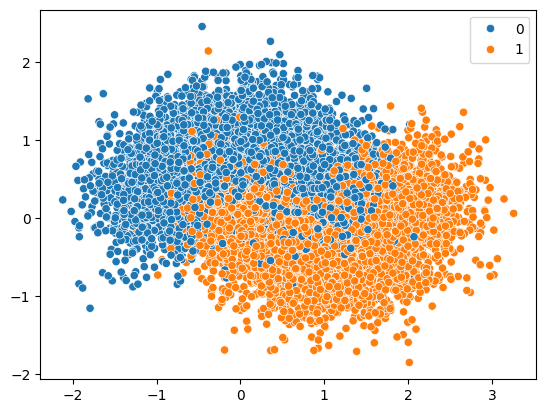

In [6]:
sns.scatterplot(x = X_moons[:,0], y = X_moons[:,1], hue = y_moons)

### Ejercicio 2

El objetivo de los modelos que vamos a ir construyendo es aprender a clasificar correctamente en cada "luna" (moon) a un punto dadas sus coordenadas. Para ello crea un par de juegos X,y para train y test al 20% de test a partir de los puntos generados en el ejercicio anterior.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_moons, y_moons, test_size = 0.20, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(8000, 2)
(2000, 2)
(8000,)
(2000,)


### Ejercicio 3

Instancia un árbol de decisión de `sklearn` sin añadir hiperparámetros.

In [8]:
clf_moons = DecisionTreeClassifier()

### Ejercicio 4

Entrena el árbol y evalúalo contra test, usa para ello el classification_report de `sklearn`

In [9]:
clf_moons.fit(X_train, y_train)
y_pred = clf_moons.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.79      0.79      1004
           1       0.79      0.80      0.79       996

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.79      0.79      0.79      2000



### Ejercicio 5

Instancia un nuevo árbol con los hiperparámetros (argumentos del constructor), `max_depth` a 5 y `max_leaf_nodes` a 15. Busca en la documentación de `sklearn` el significado de ambos hiperparámetros.

In [25]:
clf_moons_2 = DecisionTreeClassifier(max_depth = 5, max_leaf_nodes = 15)
'''
max_depth : int, valor predeterminado=Ninguna
La profundidad máxima del árbol. Si es Ninguna, los nodos se expanden hasta que todas las hojas sean puras o hasta que todas las hojas contengan menos de
min_samples_split muestras(por default = 2).

max_leaf_nodes : int, predeterminado=Ninguno
Cultiva un árbol con ``max_leaf_nodes`` priorizando los mejores nodos.
Los mejores nodos se definen como la reducción relativa de impurezas.
Si es Ninguno, el número de nodos hoja es ilimitado.

'''

'\nmax_depth : int, valor predeterminado=Ninguna\nLa profundidad máxima del árbol. Si es Ninguna, los nodos se expanden hasta que todas las hojas sean puras o hasta que todas las hojas contengan menos de\nmin_samples_split muestras(por default = 2).\n\nmax_leaf_nodes : int, predeterminado=Ninguno\nCultiva un árbol con ``max_leaf_nodes`` priorizando los mejores nodos.\nLos mejores nodos se definen como la reducción relativa de impurezas.\nSi es Ninguno, el número de nodos hoja es ilimitado.\n\n'

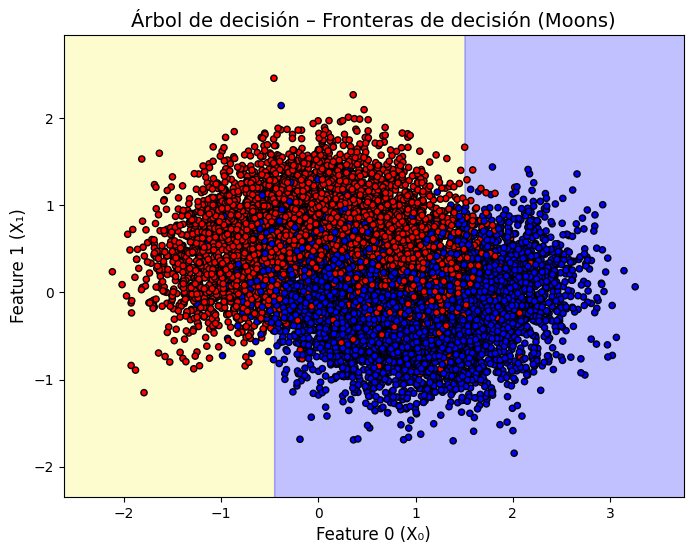

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Elegimos el clasificador entrenado
clf = clf_moons_2

# Límites del plano (ajustados a moons)
x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5

# Creamos una grilla
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Predicción sobre toda la grilla
X_grid = np.c_[xx.ravel(), yy.ravel()]
Z = clf.predict(X_grid)
Z = Z.reshape(xx.shape)

# Colores para regiones
cmap_background = ListedColormap(["#fafab0", "#9898ff"])
cmap_points = ListedColormap(["#ff0000", "#0000ff"])

# Plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=cmap_background, alpha=0.6)

# Puntos reales
plt.scatter(
    X_moons[:, 0], X_moons[:, 1],
    c=y_moons,
    cmap=cmap_points,
    edgecolor="k",
    s=20
)

# Etiquetas
plt.xlabel("Feature 0 (X₀)", fontsize=12)
plt.ylabel("Feature 1 (X₁)", fontsize=12)
plt.title("Árbol de decisión – Fronteras de decisión (Moons)", fontsize=14)

plt.show()


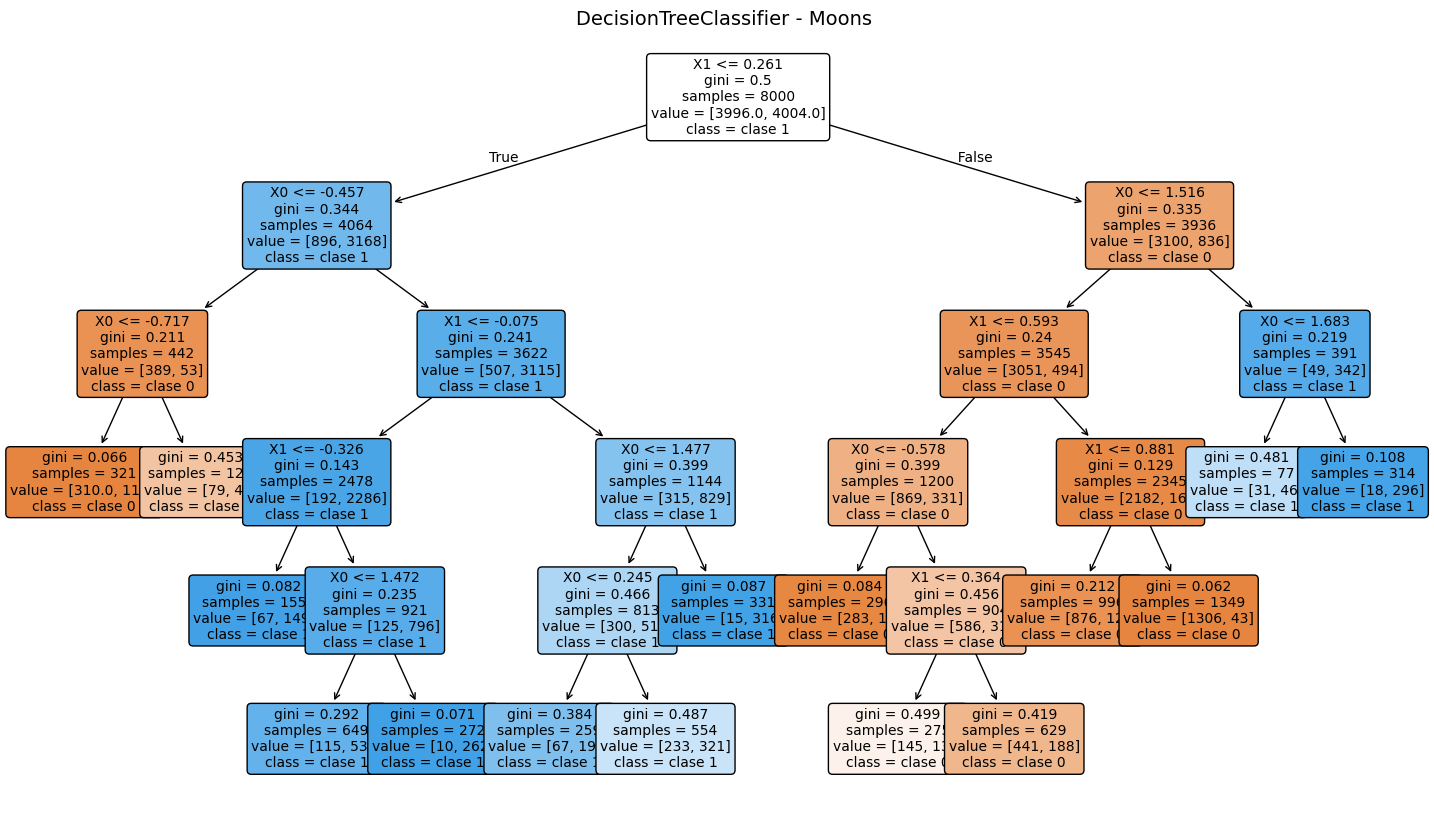

In [29]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Elegí el árbol que querés graficar (ajustá el nombre)
clf = clf_moons_2   # o clf_moons, el que corresponda

plt.figure(figsize=(18, 10))
plot_tree(
    clf,
    filled=True,
    rounded=True,
    feature_names=["X0", "X1"],  # tus 2 features de moons
    class_names=["clase 0", "clase 1"],
    impurity=True,              # muestra gini
    proportion=False,           # si True, muestra proporciones en vez de conteos
    fontsize=10
)
plt.title("DecisionTreeClassifier - Moons", fontsize=14)
plt.show()


### Ejercicio 6

Entrénalo, evaluálo contra test y muestra el resultado a través del classification_report.

In [27]:
clf_moons_2.fit(X_train, y_train)
y_pred = clf_moons_2.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.85      0.86      1004
           1       0.85      0.86      0.86       996

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



Comenta el resultado

*La mejor es sensible, debido a que el ajuste de hiperparámetros ha sido bastante bueno. En general los modelos basados en árboles necesitan un ajuste más fino que las regresiones (lineal, que apenas hay que hacer nada, y logística)*

### Ejercicio 7

Genera 1000 subconjuntos a partir del X_train, cada uno con 100 instancias seleccionadas aleatoriamente. Pista: Revisa la clase `ShuffleSplit` de `sklearn` para ayudarte con esto

In [32]:
from sklearn.model_selection import ShuffleSplit

# Generador de splits
rs = ShuffleSplit(
    n_splits=1000,
    train_size=100,   # ← CLAVE: tamaño fijo del subconjunto
    random_state=42
)

# Listas donde guardar los subconjuntos
X_subsets = []
y_subsets = []

# Generación de los 1000 subconjuntos
for train_idx, _ in rs.split(X_train):
    X_subsets.append(X_train[train_idx])
    y_subsets.append(y_train[train_idx])


### Ejercicio 8

Entrena un árbol de decisión por cada subconjunto anterior (ve acumulándolos en una lista, llámala "bosque" o "forest"). Emplea como hiperparámetros los del ejercicio 5.

In [39]:
from sklearn.tree import DecisionTreeClassifier

forest = []

for train_idx, _ in rs.split(X_train):
    X_sub = X_train[train_idx]
    y_sub = y_train[train_idx]

    # Un árbol nuevo por subconjunto (mismos hiperparámetros del ejercicio 5)
    tree = DecisionTreeClassifier(max_depth=5, max_leaf_nodes=15, random_state=42)

    # Entrenar y guardar
    tree.fit(X_sub, y_sub)
    forest.append(tree)

print(len(forest))       # debería dar 1000
print(forest[0])         # debería mostrar DecisionTreeClassifier(...)


1000
DecisionTreeClassifier(max_depth=5, max_leaf_nodes=15, random_state=42)


### Ejercicio 9

Evalua cada árbol del bosque contra X_test original en la métrica de `accuracy` y muestra la media de todas las medidas. Emplea para ello `accuracy_score` de `sklearn`. Comenta el resultado.

In [40]:
from sklearn.metrics import accuracy_score

accuracies = []

# Evaluamos cada árbol del bosque contra el MISMO X_test
for tree in forest:
    y_pred = tree.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

# Media de accuracy
mean_accuracy = np.mean(accuracies)

print(f"Accuracy media del bosque: {mean_accuracy:.3f}")


Accuracy media del bosque: 0.798


*Como era un poco de esperar un árbol entrenado con menor cantidad de datos no está a la altura de otro entrenado sobre el mismo dataset pero con mayor cantidad de información (81% vs 86%). Es lo que se denomina weak_learner*

### Ejercicio 10

Vamos a hacer un consejo de árboles... Es decir ahora vuelve a predecir las instancias de X_test para cada árbol pero guarda las predicciones en una lista. Es decir crea una lista con los 1000 conjuntos de predicciones (uno por cada árbol)

In [45]:
predicciones_list = []
for tree in forest:
    y_pred = tree.predict(X_test)
    predicciones_list.append(y_pred)

### Ejercicio 11

Ahora vamos a construir la predicción final del consejo de árboles mediante un mecanismo de "hard-voting" es decir para cada predicción escoge la clase más votada. Puedes hacerlo recorriendo cada lista de predicciones y contando cual clase tiene más votos y apuntándolo o usando `mode` (la moda) de `scipy`

In [53]:
# # Ejemplo de votación para la primera instancia de X_test
# Y_pred_consejo = []
# votos_0 = 0
# votos_1 = 0
# n_trees = len(predicciones_list)
# for i in range(n_trees):
#     if predicciones_list[i][0] == 0:
#         votos_0 += 1
#     else:
#         votos_1 += 1

# if votos_0 > votos_1:
#     Y_pred_consejo.append(0)
# else:
#     Y_pred_consejo.append(1)

n_trees = len(predicciones_list)
n_test = len(predicciones_list[0])

y_pred_consejo = []

for j in range(n_test):          # recorro instancias de X_test
    votos_0 = 0
    votos_1 = 0

    for i in range(n_trees):     # recorro árboles
        if predicciones_list[i][j] == 0:
            votos_0 += 1
        else:
            votos_1 += 1

    if votos_0 > votos_1:
        y_pred_consejo.append(0)
    else:
        y_pred_consejo.append(1)

y_pred_consejo = np.array(y_pred_consejo)


In [56]:
y_pred_consejo.shape        # (2000,)
np.unique(y_pred_consejo)  # debería ser [0 1]
y_pred_consejo

array([0, 0, 1, ..., 1, 0, 0], shape=(2000,))

### Ejercicio 12

Evalua las predicciones del consejo contra y_test y comenta el resultado. Utiliza `accuracy_score`

In [60]:
from sklearn.metrics import accuracy_score

acc_consejo = accuracy_score(y_test, y_pred_consejo)
print(f"Accuracy del consejo (hard-voting): {acc_consejo:.3f}")


Accuracy del consejo (hard-voting): 0.864


El consejo de árboles mediante hard-voting presenta una accuracy muy similar a la de un árbol individual bien regularizado. Esto se explica porque el árbol base ya tiene baja varianza gracias al ajuste de hiperparámetros. El ensemble aporta principalmente robustez y estabilidad frente a la variabilidad del muestreo, más que una mejora sustancial en la métrica de accuracy.